# Storage

*[CEGM1000 MUDE](http://mude.citg.tudelft.nl/)*

*Written by: Ronald Brinkgreve, Anna Störiko*

*Due: Wednesday, September 9, 2026.*

# Part 2: Numerical solution of a linear ODE

## Reservoir storage and discharge

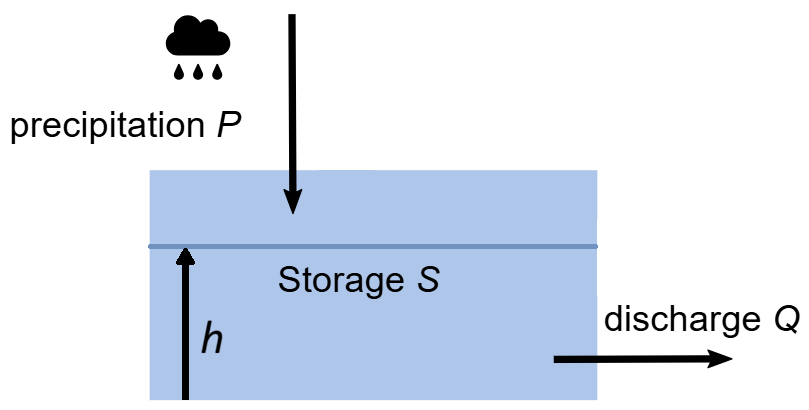

As a measure to cope with climate change, the municipality of a metropolis considers the construction of a big underground reservoir collecting rainwater for a part of the city as a buffer in periods of heavy rain, to prevent urban flooding. Above the minimum water level $h_{min}$, which acts as a reserve for the fire brigade to intake water for fire extinction, water can outflow the reservoir into the sewage system with reduced capacity. As a simplification, this outflow discharge is assumed proportional to the water level above the minimum level. Hence, the water level in the reservoir depends on both precipitation and discharge, while the latter is zero below the minimum level. If it rains heavily, the reservoir is filled up ($h$ will increase) and in case of little or no rain, the reservoir will empty ($h$ will decrease) down to the minimum level. The simplified system can be described by the following ordinary differential equation (ODE):

$$A_R\frac{dh}{dt} = A P(t)/1000 - K \left(h - h_{min} \right)$$

where:</p>
    $h$ is the water level in the reservoir</p>
    $t$ is the time</p>
    $A_R$ is the storage area of the reservoir</p>
    $A$ is the total area above ground from which precipitation is collected</p>
    $P(t)$ is the precipitation (measured on frequent regular time intervals in $mm/hour$)</p>
    $K$ is a term that defines the proportionality of the discharge with respect to the water level in $m^2/hour$

All areas are defined in $m^2$, while $h$ is defined in $m$ and $t$ in $hour$.

The maximum reservoir depth is 20 m. The idea is to design the size (base area) of the reservoir ($A_R$) based on a design precipitation scheme of 200 mm in 48 hours, using an initial estimate of 7000 $m^2$ (the size of a football field).

>
>**Task 2.1**
>
>Run the cells below to visualise the precipitation in the considered 48 hour time frame:
>

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
import numpy as np

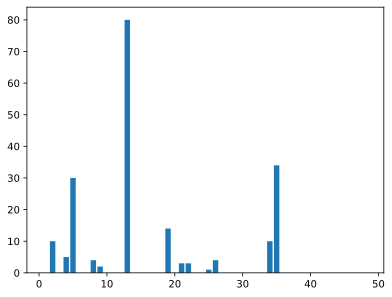

Total discharge in 48 hours: 200 mm


In [2]:
AR = 7000       # Reservoir's base area
A  = 1000000    # Precipitation collection area (1 km^2)
K  = 200        # Discharge factor
h_min = 2.0     # Minimum reservoir level

hours = 48
t_data = np.arange(1, hours + 1)

P_data = np.array([0, 10, 0, 5, 30, 0, 0, 4, 2, 0, 0, 0, 80, 0, 0, 0, 0, 0, 14, 0, 3, 3, 0,
             0, 1, 4, 0, 0, 0, 0, 0, 0, 0, 10, 34, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

plt.bar(t_data, P_data)
plt.show()

print(f'Total discharge in 48 hours: {np.sum(P_data)} mm')

(Alternatively, read an input file with precipitation data)

>
>**Task 2.2**
>
>Formulate the Forward Euler scheme for the above ODE and elaborate this into an expression for $h$ at the next time step ($h_{i+1}$).
>

**Setting up Forward Euler:**

Starting from the ODE:

$$A_R \frac{dh}{dt} = \frac{A \, P(t)}{1000} - K(h - h_{min})$$

The Forward Euler scheme approximates the derivative using a forward difference, evaluated using known values at the *current* time step $i$:

$$\frac{dh}{dt} \approx \frac{h_{i+1} - h_i}{\Delta t}$$

Substituting this into the ODE, evaluated at time step $i$ (so $P(t) = P_i$ and $h = h_i$ on the right-hand side):

$$A_R \frac{h_{i+1} - h_i}{\Delta t} = \frac{A \, P_i}{1000} - K(h_i - h_{min})$$

**Solving for $h_{i+1}$:**

$$h_{i+1} = h_i + \frac{\Delta t}{A_R}\left[\frac{A \, P_i}{1000} - K(h_i - h_{min})\right]$$



>
>**Task 2.3**
>
>Complete and run the code cells below to calculate $h_{i+1}$ for all time steps until the end of the time interval, considering $h_0 = h_{min}$.


### Data initialisation

In [3]:
# Define the time step and create solution time points
dt = 0.1        # 0.1 hours = 6 minutes
num = int(hours / dt)
print(f"Number of time steps: {num}")
t = np.linspace(0, hours, num+1)

# Interpolate precipitation data to solution time points
indices = np.searchsorted(t_data, t, side='left')
P = P_data[indices]

assert len(P) == len(t)


Number of time steps: 480


### Forward Euler scheme

In [4]:
h = np.zeros_like(t)  # create an array to store the reservoir level at each time step

h[0] = h_min  # initial condition: h0 = h_min

for i in range(num):
    h[i+1] = h[i] + dt / AR * (A * P[i] / 1000 - K * (h[i] - h_min))

>
>**Task 2.4**
>
>Run the code cell below to plot the results
>

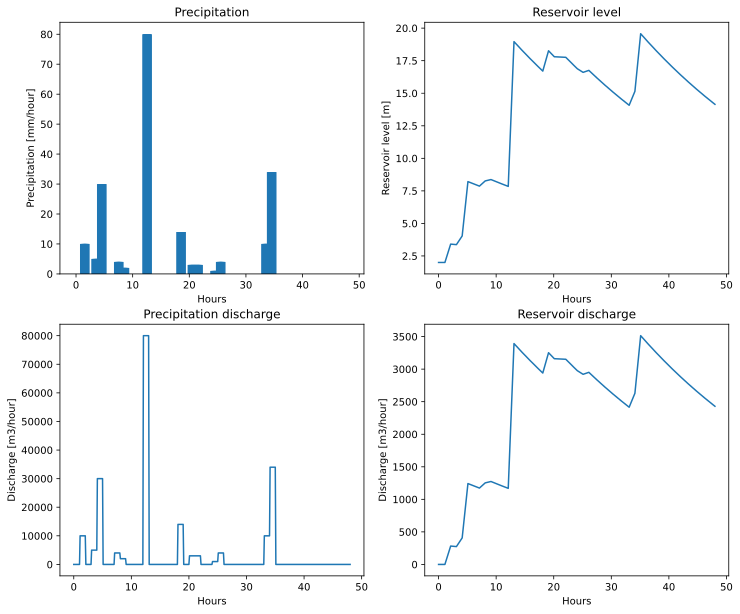

In [5]:
def plot_figs():
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    ax[0,0].bar(t, P, label='Precipitation')
    ax[0,0].set_xlabel('Hours')
    ax[0,0].set_ylabel('Precipitation [mm/hour]')
    ax[0,0].set_title('Precipitation')

    ax[0,1].plot(t, h, label='Reservoir level')
    ax[0,1].set_xlabel('Hours')
    ax[0,1].set_ylabel('Reservoir level [m]')
    ax[0,1].set_title('Reservoir level')

    ax[1,0].plot(t, P*A/1000, label='Precipitation discharge')
    ax[1,0].set_xlabel('Hours')
    ax[1,0].set_ylabel('Discharge [m3/hour]')
    ax[1,0].set_title('Precipitation discharge')

    ax[1,1].plot(t, K*(h-h_min), label='Reservoir discharge')
    ax[1,1].set_xlabel('Hours')
    ax[1,1].set_ylabel('Discharge [m3/hour]')
    ax[1,1].set_title('Reservoir discharge')

plot_figs()

>
>**Task 2.5**
>
>Write a function (print_max()) to print the maximum values of:
>* The reservoir level
>* The maximum discharge flowing into the reservoir according to the design precipitation scheme
>* The maximum discharge from the reservoir
>

In [6]:
def print_max():
    Q_in = A * P / 1000       # inflow discharge, m³/hour
    Q_out = K * (h - h_min)   # outflow discharge, m³/hour

    print(f"Maximum reservoir level: {np.max(h):.2f} m")
    print(f"Maximum inflow discharge: {np.max(Q_in):.2f} m³/hour")
    print(f"Maximum outflow discharge: {np.max(Q_out):.2f} m³/hour")

print_max()

Maximum reservoir level: 19.57 m
Maximum inflow discharge: 80000.00 m³/hour
Maximum outflow discharge: 3514.27 m³/hour


>
>**Task 2.6**
>
>Verify (analytically) the stability of the Forward Euler solution. Give the expression for the condition of stability. 
>

**Stability analysis of Forward Euler:**

The ODE has the form:

$$\frac{dh}{dt} = \frac{A \, P(t)}{1000 \, A_R} - \frac{K}{A_R}(h - h_{min})$$

Stability is governed by how errors in $h$ grow or shrink over time, which depends only on the right part of the equation (the term that depends on $h$ itself):

$$\frac{dh}{dt} = -\frac{K}{A_R}(h - h_{min})$$

This has the standard linear form $\frac{dy}{dt} = -\lambda y$ (with $\lambda = K/A_R > 0$, and $y = h - h_{min}$).

**Applying Forward Euler to this homogeneous equation:**

$$y_{i+1} = y_i + \Delta t \cdot (-\lambda y_i) = (1 - \lambda \Delta t)\, y_i$$

This means each time step multiplies the error by a factor $(1 - \lambda \Delta t)$. For the solution to remain stable, this amplification factor must satisfy:

$$|1 - \lambda \Delta t| \leq 1$$

**Solving this inequality:**

$$-1 \leq 1 - \lambda \Delta t \leq 1$$

The right inequality ($1 - \lambda \Delta t \leq 1$) is always true for $\Delta t, \lambda > 0$. The left inequality gives:

$$-1 \leq 1 - \lambda \Delta t \implies \lambda \Delta t \leq 2 \implies \Delta t \leq \frac{2}{\lambda}$$

**Stability condition:**

$$\Delta t \leq \frac{2}{\lambda} = \frac{2 A_R}{K}$$

**Interpretation:** for the given values ($A_R = 7000\ \text{m}^2$, $K = 200\ \text{m}^2/\text{hour}$), this gives:

$$\Delta t \leq \frac{2 \times 7000}{200} = 70 \text{ hours}$$

Since the chosen time step $\Delta t = 0.1$ hours is far below this threshold, the Forward Euler scheme is comfortably stable for this problem.


>
>**Task 2.7**
>
>Formulate the Backward (Implicit) Euler scheme for the above ODE and elaborate this into an expression for $h$ at the next time step ($h_{i+1}$).
>
>Hints: 
>* Refer to next week's lecture or Section 1.2 in the book for an application of the Backward Euler scheme:
>* It may be useful to introduce $h^*$ as an offset to $h$ considering $h_{min}$:
>
>$$h^* = h - h_{min} $$

**Setting up Backward Euler:**

Starting from the ODE:

$$A_R \frac{dh}{dt} = \frac{A \, P(t)}{1000} - K(h - h_{min})$$

Using the hint, substitute $h^* = h - h_{min}$ (so $\frac{dh^*}{dt} = \frac{dh}{dt}$, since $h_{min}$ is constant):

$$A_R \frac{dh^*}{dt} = \frac{A \, P(t)}{1000} - K \, h^*$$

The Backward Euler scheme approximates the derivative the same way as Forward Euler, but evaluates the **right-hand side at the next (unknown) time step** $i+1$ instead of the current one:

$$A_R \frac{h^*_{i+1} - h^*_i}{\Delta t} = \frac{A \, P_{i+1}}{1000} - K \, h^*_{i+1}$$

**Solving for $h^*_{i+1}$:**

Multiply through by $\Delta t$:

$$A_R (h^*_{i+1} - h^*_i) = \Delta t \left(\frac{A \, P_{i+1}}{1000} - K \, h^*_{i+1}\right)$$

Expand and collect all $h^*_{i+1}$ terms on the left:

$$A_R h^*_{i+1} + \Delta t \, K \, h^*_{i+1} = A_R h^*_i + \Delta t \, \frac{A \, P_{i+1}}{1000}$$

$$h^*_{i+1} (A_R + \Delta t \, K) = A_R h^*_i + \Delta t \, \frac{A \, P_{i+1}}{1000}$$

$$h^*_{i+1} = \frac{A_R h^*_i + \Delta t \, \dfrac{A \, P_{i+1}}{1000}}{A_R + \Delta t \, K}$$

**Converting back to $h$** (substituting $h^*_i = h_i - h_{min}$ and $h^*_{i+1} = h_{i+1} - h_{min}$):

$$h_{i+1} = h_{min} + \frac{A_R (h_i - h_{min}) + \Delta t \, \dfrac{A \, P_{i+1}}{1000}}{A_R + \Delta t \, K}$$



>
>**Task 2.8**
>    
>Complete and run the code cell below to calculate $h_{i+1}$ for all time steps until the end of the time interval using the Backward Euler scheme.
>

### Backward Euler scheme

In [7]:
h_star = np.zeros_like(t)

h_star[0] = 0  # since h0 = h_min, h_star0 = h0 - h_min = 0

for i in range(num):
    h_star[i+1] = (AR * h_star[i] + dt * A * P[i+1] / 1000) / (AR + dt * K)

h = h_min + h_star

Plotting the results

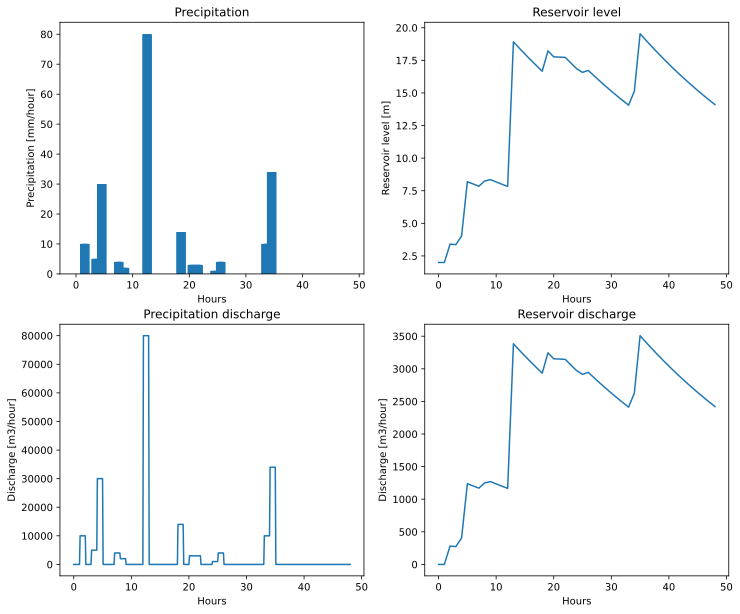

In [8]:
plot_figs()

printing the maximum values

In [9]:
print_max()

Maximum reservoir level: 19.54 m
Maximum inflow discharge: 80000.00 m³/hour
Maximum outflow discharge: 3508.59 m³/hour


>
>**Task 2.9**
>
>Comment on the suitability of the reservoir in terms of:
>* Its capacity in view of the design precipitation scheme
>* Its capacity in view of the total design precipitation in 48 hours (what if the precipitation distribution over 48 hours is different?)
>* Its function to act as a buffer preventing overflow of the sewage system
>
>What would you advise the municipality?
>

**Task 2.9 — Suitability of the reservoir**

**Capacity vs. the design storm:**
The reservoir almost fills up, reaching about 19.5–19.6 m out of a 20 m max depth. This leaves very little safety margin, something like a slightly bigger storm could cause it to overflow.

**Capacity vs. total rain in 48 hours:**
The total rainfall (200 mm) matches the design, but *how* it falls matters too. This storm has short, heavy bursts (like the 80 mm spike), which fill the reservoir fast. If the same 200 mm fell more evenly over 48 hours, the reservoir would likely stay much lower, since outflow would have more time to keep up. So a reservoir sized for one rain pattern might not be safe for a different pattern with the same total.

**Buffering the sewage system:**
The peak inflow (80,000 m³/hour) is far higher than the peak outflow (~3,500 m³/hour) — over 20 times more. This shows the reservoir is working as intended: it holds back a big incoming amount of water and releases it slowly, protecting the sewage system from a spike it couldn't handle on its own.

**Advice to the municipality:**
The reservoir works, but its capacity is too tight, it almost overflows even under the exact design storm. I'd recommend making it bigger or adding a safety margin, and testing it against several different rain patterns, not just one. This is especially important given climate change is likely to bring heavier, more concentrated storms in the future.

> By Ronald Brinkgreve and Anna Störiko, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).